# MLP_MWeighted Model

In [22]:
# import libraries
from sklearn.metrics.pairwise import cosine_similarity as cosine
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import torch
pd.options.display.float_format = '{:,.2f}'.format

np.set_printoptions(threshold=np.inf)

In [2]:
#data from https://github.com/aliannejadi/istas

df=pd.read_json("data/istas.json")
df

,timestamp,UserID,Query,App,AppUsages
0,2018-04-14 13:28:32.655,54,"peoria, il post office, glen ave",google,"{'Duration': {'???': 1128776, 'android_system'..."
1,2018-04-14 19:06:05.105,54,"peoria, il weather",chrome,"{'Duration': {'???': 1128776, 'android_system'..."
10,2018-04-17 14:43:36.174,54,paypal/prepaid,google,"{'Duration': {'???': 538689, 'achievement': 39..."
100,2018-04-27 06:51:59.737,41,nose rod exam,puffin,"{'Duration': {'accessibility': 26381, 'all-in-..."
1000,2018-04-16 19:20:12.848,246,random alphanumeric generator,google,"{'Duration': {'ally_mobile': 50046, 'android_s..."
...,...,...,...,...,...
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
995,2018-04-16 14:41:01.883,126,why are the disney cartoons in spanish today,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
997,2018-04-16 17:01:06.085,246,weather hope mills,google,"{'Duration': {'ally_mobile': 50046, 'android_s..."
998,2018-04-16 17:03:38.204,246,kakuriyo,chrome,"{'Duration': {'ally_mobile': 50046, 'android_s..."


In [3]:
# find the most frequent UserID

most_frequent_userID = df['UserID'].value_counts().idxmax()
df_filtered = df[df['UserID'] == most_frequent_userID]

df_filtered

,timestamp,UserID,Query,App,AppUsages
613,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,"{'Duration': {'???': 470631, 'android_system':..."
615,2018-04-03 20:37:08.728,126,looked at phone bill,my_account,"{'Duration': {'???': 470631, 'android_system':..."
617,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,"{'Duration': {'???': 470631, 'android_system':..."
618,2018-04-03 20:42:14.269,126,text my brother about working,messages,"{'Duration': {'???': 470631, 'android_system':..."
619,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,"{'Duration': {'???': 470631, 'android_system':..."
...,...,...,...,...,...
991,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
992,2018-04-16 02:45:09.050,126,mturk info script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
993,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep..."


In [4]:
from collections import Counter

# remove the rows with app that only appear once

app_counts = df_filtered['App'].value_counts()
df_filtered = df_filtered[df_filtered['App'].isin(app_counts[app_counts > 1].index)]

df_filtered

,timestamp,UserID,Query,App,AppUsages
613,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,"{'Duration': {'???': 470631, 'android_system':..."
615,2018-04-03 20:37:08.728,126,looked at phone bill,my_account,"{'Duration': {'???': 470631, 'android_system':..."
617,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,"{'Duration': {'???': 470631, 'android_system':..."
619,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,"{'Duration': {'???': 470631, 'android_system':..."
620,2018-04-03 20:43:36.262,126,kum and go,yahoo_mail,"{'Duration': {'???': 470631, 'android_system':..."
...,...,...,...,...,...
991,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
992,2018-04-16 02:45:09.050,126,mturk info script,chrome,"{'Duration': {'android_system': 32594, 'badgep..."
993,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,"{'Duration': {'android_system': 63575, 'badgep..."
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep..."


In [ ]:
df_filtered['App'] = df_filtered['App'].str.replace(r'[^\w\s]', ' ', regex=True)  
df_filtered['App'] = df_filtered['App'].str.replace(r'_', '')

apps = df_filtered['App'].unique()
print(apps)

In [6]:
import requests
import time
from bs4 import BeautifulSoup
from fake_useragent import UserAgent

In [10]:
#build a fake user agent to avoid being blocked https://stackoverflow.com/questions/27652543/how-can-i-use-pythons-requests-to-fake-a-browser-visit-a-k-a-and-generate-user

#!pip install fake-useragent

In [7]:
#https://www.crummy.com/software/BeautifulSoup/bs4/doc/

def get_package_name(app_name):
    
    # build the search URL
    # try avoid getting banned by the server while performing consecutive requests, but should be fine for a small number of requests
    
    ua = UserAgent()
    
    headers = {'User-Agent':str(ua.chrome)}
    url = "https://play.google.com/store/search"
    params = {"q": app_name, "c": "apps"}

    response = requests.get(url, params=params, headers=headers)

    if response.status_code != 200:
        return None

    # get the link of the first result
    soup = BeautifulSoup(response.text, 'html.parser')
    app_link = soup.find('a', href=True, class_='Qfxief')  

    # since there are two different layouts for the search results, find in this class if the previous one is not found
    if not app_link:
        app_link = soup.find('a', href=True, class_='Si6A0c Gy4nib')

    # avoid getting banned by the server while performing consecutive requests
    time.sleep(1) 

    # get the package name 
    if app_link:
        return app_link['href'].split('id=')[1]  
    return None


def get_app_category(app_package_name):
    
    # build the URL for the app details page
    app_details_url = f"https://play.google.com/store/apps/details?id={app_package_name}"

    response = requests.get(app_details_url)

    if response.status_code != 200:
        return None

    soup = BeautifulSoup(response.text, 'html.parser')

    # look for the category tag
    category_tag = soup.find('a', class_='WpHeLc VfPpkd-mRLv6 VfPpkd-RLmnJb')

    time.sleep(1) 

    if category_tag and 'aria-label' in category_tag.attrs:
        return category_tag['aria-label']
    else:
        return None


for app_name in apps:   
   
    package_name = get_package_name(app_name)
    
    # if the package name is not found, mark the category as unknown
    category = get_app_category(package_name) if package_name else "unknown"


app_category_dict = {}

# go through each app name and get the package name
for app_name in apps:

    package_name = get_package_name(app_name)

  
    if package_name:
        category = get_app_category(package_name)
    else:
        category = "Unknown"

    app_category_dict[app_name] = category


    print(f"App: {app_name}, Category: {category}")


df_filtered['category'] = df_filtered['App'].map(app_category_dict)


df_filtered

App: classdojo, Category: Education
App: myaccount, Category: House & Home
App: messenger, Category: Communication
App: calendar, Category: Productivity
App: yahoomail, Category: Communication
App: google, Category: Tools
App: facebook, Category: Social
App: chrome, Category: Communication
App: youtube, Category: Video Players & Editors
App: weather, Category: Weather
App: amazonshopping, Category: Shopping
App: instagram, Category: Social
App: googleplaystore, Category: Entertainment
App: maps, Category: Travel & Local
App: weatherforecast, Category: Weather


C:\Users\tobys\AppData\Local\Temp\ipykernel_7160\192487495.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['category'] = df_filtered['App'].map(app_category_dict)


,timestamp,UserID,Query,App,AppUsages,category
613,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,"{'Duration': {'???': 470631, 'android_system':...",Education
615,2018-04-03 20:37:08.728,126,looked at phone bill,myaccount,"{'Duration': {'???': 470631, 'android_system':...",House & Home
617,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,"{'Duration': {'???': 470631, 'android_system':...",Communication
619,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,"{'Duration': {'???': 470631, 'android_system':...",Productivity
620,2018-04-03 20:43:36.262,126,kum and go,yahoomail,"{'Duration': {'???': 470631, 'android_system':...",Communication
...,...,...,...,...,...,...
991,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,"{'Duration': {'android_system': 32594, 'badgep...",Communication
992,2018-04-16 02:45:09.050,126,mturk info script,chrome,"{'Duration': {'android_system': 32594, 'badgep...",Communication
993,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,"{'Duration': {'android_system': 63575, 'badgep...",Communication
994,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,"{'Duration': {'android_system': 63575, 'badgep...",Communication


In [8]:
# encode the category column

from sklearn.preprocessing import OneHotEncoder

app_categories = df_filtered['category'].values.reshape(-1, 1)

encoder = OneHotEncoder()
app_category_encoded = encoder.fit_transform(app_categories).toarray()

In [10]:
# check the sparsity of the data
total_val = app_category_encoded.size
non_zero_val = app_category_encoded.astype(bool).sum().sum()
percentage_non_zero = (non_zero_val / total_val) * 100
print(percentage_non_zero, '%')

9.090909090909092 %


In [11]:
# use PCA to reduce the dimensions of the data
pca = PCA(n_components=0.95)
category_reduced = pca.fit_transform(app_category_encoded)

In [ ]:
# https://huggingface.co/docs/transformers/en/installation
#!pip install transformers

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.9 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.5 MB 2.0 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.5 MB 3.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 5.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB ? eta -:--:--
   --------------------------------- ------ 1.8/2.2 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.9 MB/s eta 0:00:00


In [12]:
# use BERT for query embedding   https://www.geeksforgeeks.org/how-to-generate-word-embedding-using-bert/
from transformers import BertTokenizer, BertModel

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_BERT = BertModel.from_pretrained('bert-base-uncased')

c:\Users\tobys\miniconda3\envs\nlp\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [13]:
queries = df_filtered['Query'].tolist()

# tokenization for the queries
encoded_query = tokenizer.batch_encode_plus(queries,# List of input texts
    padding=True,              # Pad to the maximum sequence length
    truncation=True,           # Truncate to the maximum sequence length if necessary
    return_tensors='pt',      # Return PyTorch tensors
    add_special_tokens=True    # Add special tokens CLS and SEP
)

input_ids = encoded_query['input_ids']
attention_mask = encoded_query['attention_mask']

# input queries in batches to save memory
batch_size = 32  
embeddings = []

# iterate over the input queries in batches
for i in range(0, len(input_ids), batch_size):
    batch_input_ids = input_ids[i:i+batch_size]
    batch_attention_mask = attention_mask[i:i+batch_size]
    
    with torch.no_grad():
        outputs = model_BERT(batch_input_ids, attention_mask=batch_attention_mask)
    
    embedding = outputs.last_hidden_state[:, 0, :]  
    embeddings.append(embedding)

# concatenate the embeddings
query_embeddings = torch.cat(embeddings, dim=0)  

print(query_embeddings.shape)  # (batch_size, seq_len, hidden_size)

torch.Size([367, 768])


In [14]:
pca = PCA(n_components=0.95)
query_reduced = pca.fit_transform(query_embeddings)

In [15]:
from sklearn.cluster import KMeans

# cluster the queries

num_clusters = 8
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

clustered_query_embeddings = np.array(query_reduced)  
cluster_labels = kmeans.fit_predict(clustered_query_embeddings)  

print(cluster_labels)

[5 2 6 1 7 1 1 1 2 1 5 1 6 6 6 1 6 6 1 6 7 7 1 3 3 6 0 6 6 6 6 7 6 0 1 7 1
 1 2 6 7 4 4 4 1 2 2 7 1 1 7 6 4 6 1 1 7 6 6 7 6 1 2 7 7 2 2 1 7 6 6 6 1 1
 6 6 5 4 1 1 1 3 6 6 6 6 6 6 6 6 1 0 0 6 6 7 1 1 1 1 1 1 1 1 0 6 2 1 1 6 6
 1 4 6 7 2 2 2 5 5 7 7 7 1 1 1 6 6 1 3 2 7 1 1 1 6 6 4 4 7 1 1 1 1 1 0 2 1
 1 0 0 6 6 6 6 1 1 1 6 6 2 6 6 7 7 4 6 1 1 6 2 3 3 1 1 1 7 4 4 7 7 1 1 4 7
 1 7 1 6 7 1 7 7 6 4 1 4 7 6 4 6 1 3 2 6 1 7 7 1 6 6 5 7 1 7 7 6 7 1 6 1 7
 3 1 1 1 2 4 1 1 1 1 1 7 1 7 6 4 1 1 0 1 6 6 1 1 6 6 1 7 3 6 6 1 1 6 6 1 0
 0 1 4 7 1 2 6 6 7 1 1 7 1 0 1 1 1 1 5 4 1 2 2 7 7 4 1 6 6 7 7 6 0 1 1 6 6
 1 2 4 4 6 1 1 1 1 6 7 3 3 3 3 1 6 1 1 2 6 7 6 1 1 7 3 3 3 4 3 3 2 3 3 2 4
 1 1 1 1 7 6 3 5 1 6 6 1 2 6 6 6 2 6 2 2 2 1 1 6 4 2 1 0 2 0 0 2 2 6]


c:\Users\tobys\miniconda3\envs\nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [16]:
from sklearn.preprocessing import MinMaxScaler

df_expanded = pd.json_normalize(df_filtered['AppUsages'].apply(lambda x: x['Duration']))

df_final = pd.concat([df_filtered.reset_index(drop=True), df_expanded.reset_index(drop=True)], axis=1)

# fill missing values with 0 and drop the AppUsages column
df_final = df_final.fillna(0)
df_final = df_final.drop(columns=['AppUsages'])

# standardize the data
scaler = MinMaxScaler()
df_final[df_expanded.columns] = scaler.fit_transform(df_final[df_expanded.columns])

# extract app usage features
app_usage_features = df_final[df_expanded.columns].values

df_final

,timestamp,UserID,Query,App,category,???,android_system,badgeprovider,beaconmanager,bluetooth_share,...,emergencyprovider,google+,kies_application_,print_spooler,video_player,scraper,wag!,turbotax,kum_&_go,samsung_internet
0,2018-04-03 20:32:45.939,126,elvis presley playlist,classdojo,Education,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2018-04-03 20:37:08.728,126,looked at phone bill,myaccount,House & Home,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,2018-04-03 20:39:30.397,126,messaged co- worker,messenger,Communication,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2018-04-03 20:42:35.219,126,set reminder for tomorrows coffee,calendar,Productivity,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,2018-04-03 20:43:36.262,126,kum and go,yahoomail,Communication,0.35,0.03,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,2018-04-16 02:44:58.307,126,mturk search engine script,chrome,Communication,0.00,0.22,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
363,2018-04-16 02:45:09.050,126,mturk info script,chrome,Communication,0.00,0.22,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
364,2018-04-16 03:17:45.470,126,which is better merilax or milk of mag,chrome,Communication,0.00,0.42,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
365,2018-04-16 05:41:03.138,126,hotel kidnapping at north spfld mo,chrome,Communication,0.00,0.42,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
pca = PCA(n_components=0.95) 
app_usage_reduced = pca.fit_transform(app_usage_features)

In [29]:
cluster_labels = cluster_labels.reshape(-1, 1)

In [30]:
print(query_reduced.shape) # (n_samples, hidden_size)
print(category_reduced.shape) # (n_samples, n_categories)
print(app_usage_reduced.shape) # (n_samples, n_apps)
print(cluster_labels.shape)

(367, 151)
(367, 7)
(367, 15)
(367, 1)


### Model Training

In [80]:
# transform numpy arrays to torch tensors
py_query_embeddings = torch.tensor(query_reduced, dtype=torch.float32)
py_app_categories = torch.tensor(category_reduced, dtype=torch.float32)
py_app_usage = torch.tensor(app_usage_reduced, dtype=torch.float32)
py_cluster_labels = torch.tensor(cluster_labels, dtype=torch.float32)

# concatenate all features
py_features = torch.cat([py_query_embeddings, py_app_categories, py_app_usage, py_cluster_labels], dim=1)
print(py_features.shape)

torch.Size([367, 174])


In [81]:
# encode the app names
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
all_apps = df_filtered['App']
py_app_labels = le.fit_transform(all_apps)

# transform the labels to tensor
tensor_labels = torch.tensor(py_app_labels, dtype=torch.long) 

In [82]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(py_features, tensor_labels, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Epoch 1, Loss: 2.706336259841919
Epoch 2, Loss: 2.698837924003601
Epoch 3, Loss: 2.6894829750061033
Epoch 4, Loss: 2.6744667053222657
Epoch 5, Loss: 2.64858455657959
Epoch 6, Loss: 2.6043800354003905
Epoch 7, Loss: 2.523976135253906
Epoch 8, Loss: 2.447463345527649
Epoch 9, Loss: 2.3656314611434937
Epoch 10, Loss: 2.328774905204773
Epoch 11, Loss: 2.2676864147186278
Epoch 12, Loss: 2.235346817970276
Epoch 13, Loss: 2.2482920408248903
Epoch 14, Loss: 2.1985025882720945
Epoch 15, Loss: 2.1712669372558593
Epoch 16, Loss: 2.1758708000183105
Epoch 17, Loss: 2.191805934906006
Epoch 18, Loss: 2.1698007106781008
Epoch 19, Loss: 2.167299723625183
Epoch 20, Loss: 2.124996781349182
Epoch 21, Loss: 2.1192036151885985
Epoch 22, Loss: 2.11785204410553
Epoch 23, Loss: 2.120165205001831
Epoch 24, Loss: 2.1118265628814696
Epoch 25, Loss: 2.1269207239151
Epoch 26, Loss: 2.106647789478302
Epoch 27, Loss: 2.1219302892684935
Epoch 28, Loss: 2.116454243659973
Epoch 29, Loss: 2.1092379331588744
Epoch 30, Los

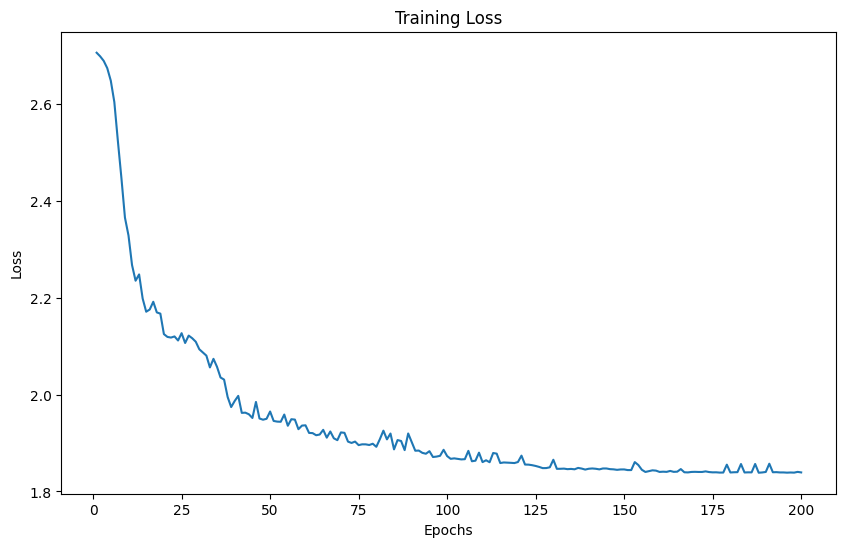

In [121]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, feature_weights):
        super(MLP, self).__init__()
        self.feature_weights = nn.Parameter(torch.tensor(feature_weights, dtype=torch.float32))  # add the feature weights as a parameter
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.5)  # to avoid overfitting
    
    def forward(self, x):
        # get the weighted input
        weighted_input = x * self.feature_weights  # do the weighting for each feature
        x = self.fc1(weighted_input)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return F.softmax(x, dim=1)


# manually set the weights for each feature https://prioritizr.net/reference/add_feature_weights.html

total_weight = 1.0
query_weight_ratio = 0.3
app_category_weight_ratio = 0.20
app_usage_weight_ratio = 0.30
cluster_label_weight_ratio = 0.2

query_weight = query_weight_ratio * total_weight
app_category_weight = app_category_weight_ratio * total_weight
app_usage_weight = app_usage_weight_ratio * total_weight
cluster_label_weight = cluster_label_weight_ratio * total_weight

# distribution of weights based on the number of features
feature_weights = [query_weight] * 151 + [app_category_weight] * 7 + [app_usage_weight] * 15 + [cluster_label_weight] * 1

# model configurations
input_size = 174  # equals to the number of features
hidden_size = 128 
output_size = len(le.classes_)
model = MLP(input_size, hidden_size, output_size, feature_weights)

# define the loss function and optimizer
criterion = nn.CrossEntropyLoss()  
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# record the loss values
loss_values = []

# train the model
for epoch in range(200):  
    model.train()
    running_loss = 0.0
    
    for features, labels in train_dataloader: 
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_dataloader)  # calculate average loss
    loss_values.append(avg_loss)
    
    print(f'Epoch {epoch+1}, Loss: {avg_loss}')

# draw the training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, 201), loss_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


### Evaluations

In [150]:
from sklearn.metrics import accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad(): 
    for features, labels in test_dataloader:
        outputs = model(features)  
        _, predicted = torch.max(outputs, 1)  
        all_preds.extend(predicted.cpu().numpy())  
        all_labels.extend(labels.cpu().numpy())  

accuracy = accuracy_score(all_labels, all_preds)
print(f"MLP_MWeighted accuracy: {accuracy * 100:.2f}%")


MLP_MWeighted accuracy: 87.84%


In [124]:
# get the mapping of app labels to app names
app_label_to_name = dict(zip(le.transform(le.classes_), le.classes_))

# get the mapping of app labels to app categories
app_label_to_category = dict(zip(le.transform(le.classes_), app_categories))

In [147]:
import torch

model.eval()


X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# get the probabilities with softmax
with torch.no_grad():
    outputs = model(X_test_tensor)  
    probs = F.softmax(outputs, dim=1).cpu().numpy()  

# choose 5 random searches
random_indices = np.random.choice(len(X_test), 5, replace=False)


query_results = []

# present the top 3 app recommendations for each query and the corresponding categories
for idx in random_indices:
    query_text = df_filtered.iloc[idx]['Query']  # get the query text from the DataFrame
    
    # get the top 3 app labels
    top_3_labels = probs[idx].argsort()[-3:][::-1]
    
    # label to app name and category
    top_3_apps = [app_label_to_name[label] for label in top_3_labels]
    top_3_categories = [app_label_to_category[label] for label in top_3_labels]
    
    
    # save the results to a dictionary
    result = {
        "query_text": query_text,
        "top_3_apps": top_3_apps,
        "top_3_categories": top_3_categories
    }
    
    query_results.append(result)


for result in query_results:
    print(f"Query: {result['query_text']}")
    print(f"Top 3 APP recommendation: {result['top_3_apps']}\n")

    clean_categories = [category[0] for category in result['top_3_categories']]  # get the first category

    print(f"Top 3 APP category: {clean_categories}\n")


Query: muppet babies dvds
Top 3 APP recommendation: ['youtube', 'chrome', 'googleplaystore']

Top 3 APP category: ['Video Players & Editors', 'Communication', 'Tools']

Query: cbs live san bruno ca
Top 3 APP recommendation: ['chrome', 'google', 'googleplaystore']

Top 3 APP category: ['Communication', 'Communication', 'Tools']

Query: mturk-payments
Top 3 APP recommendation: ['amazonshopping', 'chrome', 'calendar']

Top 3 APP category: ['Education', 'Communication', 'House & Home']

Query: elvis
Top 3 APP recommendation: ['chrome', 'classdojo', 'calendar']

Top 3 APP category: ['Communication', 'Productivity', 'House & Home']

Query: mturk
Top 3 APP recommendation: ['youtube', 'chrome', 'googleplaystore']

Top 3 APP category: ['Video Players & Editors', 'Communication', 'Tools']



C:\Users\tobys\AppData\Local\Temp\ipykernel_7160\2783759082.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)  # 确保输入是 PyTorch tensor


In [148]:
# find the actual app with query text
for result in query_results:
    actual_query = df_filtered.loc[df_filtered['Query'] == result['query_text'], 'Query']
    actual_app = df_filtered.loc[df_filtered['Query'] == result['query_text'], 'App']
    actual_category = df_filtered.loc[df_filtered['Query'] == result['query_text'], 'category']

    print(f"Query: {actual_query.values}, APP: {actual_app.values}, Category:{actual_category.values}")  


Query: ['muppet babies dvds'], APP: ['amazonshopping'], Category:['Shopping']
Query: ['cbs live san bruno ca'], APP: ['chrome'], Category:['Communication']
Query: ['mturk-payments'], APP: ['chrome'], Category:['Communication']
Query: ['elvis' 'elvis'], APP: ['youtube' 'youtube'], Category:['Video Players & Editors' 'Video Players & Editors']
Query: ['mturk' 'mturk' 'mturk' 'mturk' 'mturk'], APP: ['google' 'chrome' 'google' 'chrome' 'chrome'], Category:['Tools' 'Communication' 'Tools' 'Communication' 'Communication']


In [123]:
correct_top3 = 0
total_samples = 0

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for features, labels in test_dataloader: 
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        
        # get top-3 predictions
        _, top3_preds = torch.topk(outputs, 3, dim=1)
        
        # check if the true label is in the top-3 predictions
        correct_top3 += sum([1 if labels[i] in top3_preds[i] else 0 for i in range(labels.size(0))])
        total_samples += labels.size(0)

top3_accuracy = correct_top3 / total_samples
print(f'Top-3 Accuracy: {top3_accuracy * 100:.2f}%')

Top-3 Accuracy: 94.59%


In [122]:
def reciprocal_rank(predictions, label):
    try:
        rank = (predictions == label).nonzero(as_tuple=True)[0].item() + 1
        return 1.0 / rank
    except ValueError:
        return 0.0

mrr_total = 0
total_samples = 0

model.eval()
with torch.no_grad():
    for features, labels in test_dataloader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        
        # get the ranked predictions
        _, ranked_preds = torch.sort(outputs, descending=True, dim=1)
        
        # calculate MRR for each sample
        for i in range(labels.size(0)):
            mrr_total += reciprocal_rank(ranked_preds[i], labels[i])
        
        total_samples += labels.size(0)

mrr_score = mrr_total / total_samples
print(f'MRR: {mrr_score:.4f}')

MRR: 0.9150


In [116]:
correct_p1 = 0
total_samples = 0

model.eval()
with torch.no_grad():
    for features, labels in test_dataloader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        
        # get the top-1 predictions
        _, top1_preds = torch.max(outputs, 1)
        
        # calculate P@1
        correct_p1 += (top1_preds == labels).sum().item()
        total_samples += labels.size(0)

p1_score = correct_p1 / total_samples
print(f'Precision @ 1 (P@1): {p1_score * 100:.2f}%')

Precision @ 1 (P@1): 87.84%
